== 5 Data Teratas ==


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12364\1003351723.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_range', data=df, palette='viridis')


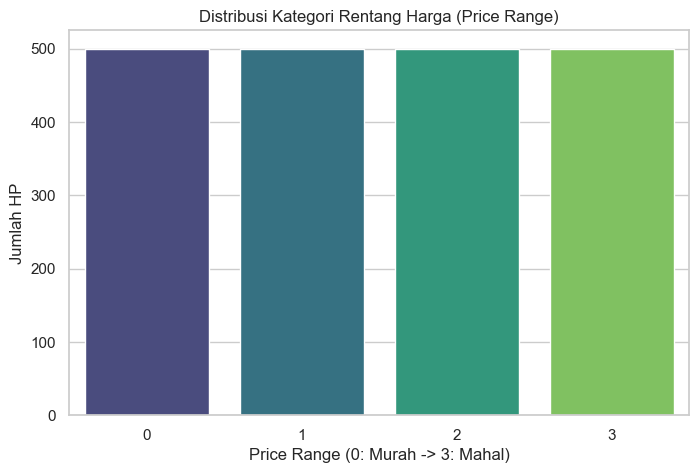

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12364\1003351723.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_range', y='ram', data=df, palette='Set2')


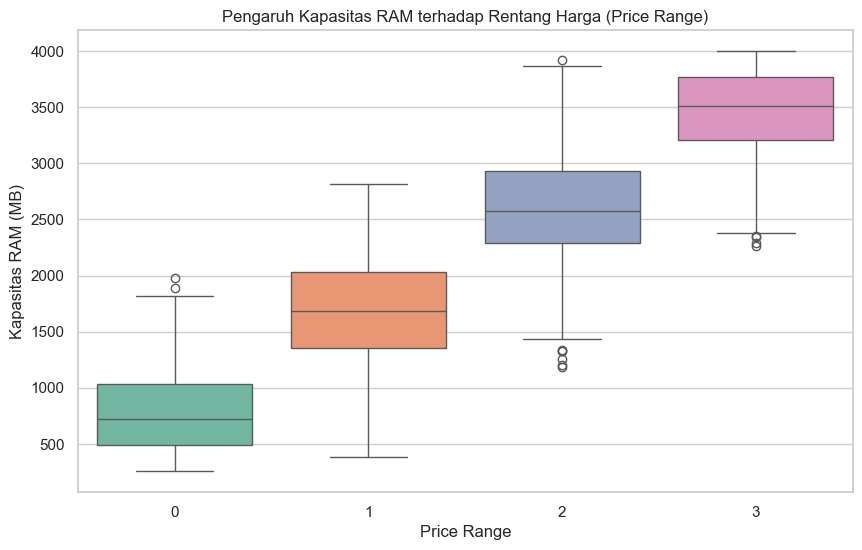

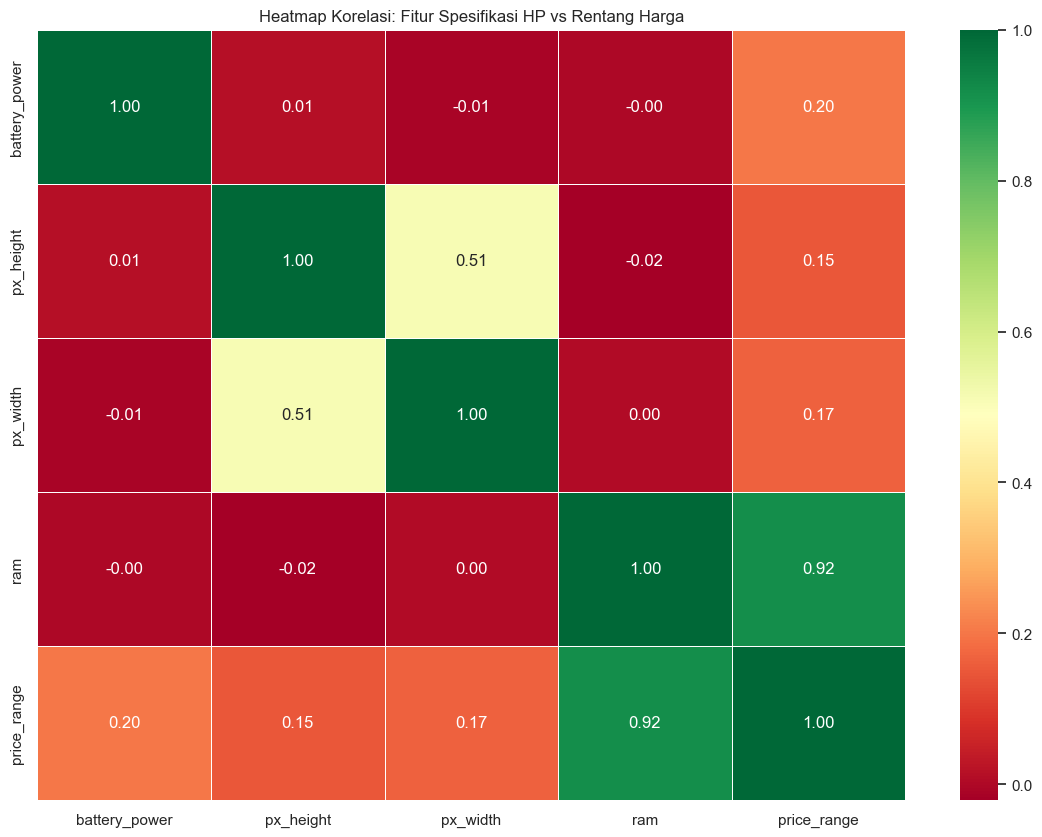

== Insight & Kesimpulan Data ==
1. Korelasi antara RAM dan Harga sangat tinggi: 0.92
2. Dari Boxplot terlihat jelas, semakin mahal HP (Price Range naik), kapasitas RAM-nya juga makin besar tanpa ada irisan yang signifikan antar kelas.
3. Berdasarkan Heatmap, fitur utama yang paling menentukan harga HP adalah: RAM, daya baterai (battery_power), dan resolusi layar (px_width & px_height).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# 1. MEMUAT DATASET & INSPEKSI AWAL
# ==========================================================
# Pastikan file 'train.csv' satu folder dengan Latihan4.ipynb
try:
    df = pd.read_csv('train.csv')
    print("== 5 Data Teratas ==")
    display(df.head())
except FileNotFoundError:
    print("Error: File 'train.csv' tidak ditemukan. Pastikan posisinya sudah benar di VS Code!")

# Mengatur gaya visualisasi
sns.set(style="whitegrid")

# ==========================================================
# 2. ANALISIS DISTRIBUSI TARGET (Count Plot)
# ==========================================================
plt.figure(figsize=(8, 5))
sns.countplot(x='price_range', data=df, palette='viridis')
plt.title('Distribusi Kategori Rentang Harga (Price Range)')
plt.xlabel('Price Range (0: Murah -> 3: Mahal)')
plt.ylabel('Jumlah HP')
plt.show()

# ==========================================================
# 3. ANALISIS KATEGORIKAL (Box Plot)
# Membandingkan kapasitas RAM terhadap Price Range
# ==========================================================
plt.figure(figsize=(10, 6))
sns.boxplot(x='price_range', y='ram', data=df, palette='Set2')
plt.title('Pengaruh Kapasitas RAM terhadap Rentang Harga (Price Range)')
plt.xlabel('Price Range')
plt.ylabel('Kapasitas RAM (MB)')
plt.show()

# ==========================================================
# 4. ANALISIS KORELASI MULTIVARIAT (Heatmap Seleksi Fitur)
# ==========================================================
# Kita cari korelasi semua fitur, lalu filter yang paling ngaruh ke price_range
plt.figure(figsize=(14, 10))
corrmat = df.corr()

# Mengambil fitur-fitur yang nilai korelasinya dengan price_range lumayan tinggi (> 0.05)
top_corr_features = corrmat.index[abs(corrmat["price_range"]) > 0.05]

sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi: Fitur Spesifikasi HP vs Rentang Harga')
plt.show()

# ==========================================================
# 5. MENAMPILKAN INSIGHT (Kesimpulan Otomatis)
# ==========================================================
print("== Insight & Kesimpulan Data ==")
korelasi_ram = corrmat.loc['ram', 'price_range']
print(f"1. Korelasi antara RAM dan Harga sangat tinggi: {korelasi_ram:.2f}")
print("2. Dari Boxplot terlihat jelas, semakin mahal HP (Price Range naik), kapasitas RAM-nya juga makin besar tanpa ada irisan yang signifikan antar kelas.")
print("3. Berdasarkan Heatmap, fitur utama yang paling menentukan harga HP adalah: RAM, daya baterai (battery_power), dan resolusi layar (px_width & px_height).")